# Import

In [31]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
%matplotlib inline

from data import prepare_CIFAR10
from model import CNN_CIFAR10
from utils import get_loss_acc

# Analysis on loss distribution

In [37]:
# prepare model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

net = CNN_CIFAR10()
net.to(device)
net.load_state_dict(torch.load("model_weights/CNN_CIFAR10_selectedtrain(shuffle).pth", map_location=device))

<All keys matched successfully>

In [9]:
# prepare dataset
trainloader, valloader, testloader = prepare_CIFAR10()
X_val, Y_val = valloader.dataset.Data, valloader.dataset.Label

40000 10000 10000


In [105]:
loss_function = nn.CrossEntropyLoss()
loss_val = []

with torch.no_grad():
    net.eval()
    for i, img in enumerate(X_val):
        img = img.to(device)
        label = Y_val[i].unsqueeze(0)
        logits = net(img.unsqueeze(0))
        loss = loss_function(logits, label)
        loss_val.append(loss.item())

loss_val = np.hstack(loss_val)

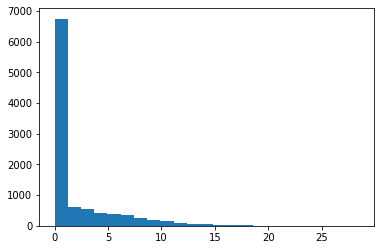

In [108]:
plt.hist(loss_val, bins=23)
plt.show()

In [107]:
np.mean(loss_val[loss_val >= 1])

5.772375536168503

In [109]:
np.mean(loss_val[loss_val <= 1])

0.08809828833811227

In [113]:
prob_val = [2**(-loss) for loss in loss_val]

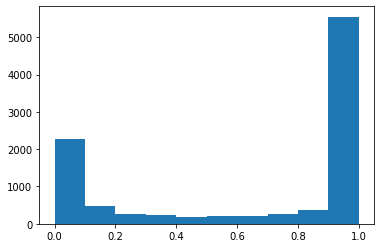

In [116]:
plt.hist(prob_val, bins=10)
plt.show()

In [112]:
2**(-5.77)

0.018325546081748113

In [67]:
count = 0
for i, img in enumerate(X_val):
    img = img.to(device)
    label = Y_val[i].unsqueeze(0)
    logits = net(img.unsqueeze(0))
    Y_pred = torch.argmax(logits, dim=1)
    print(Y_pred)
    if i == 19:
        break

tensor([6])
tensor([0])
tensor([1])
tensor([6])
tensor([1])
tensor([0])
tensor([0])
tensor([0])
tensor([8])
tensor([1])
tensor([1])
tensor([2])
tensor([2])
tensor([4])
tensor([0])
tensor([6])
tensor([4])
tensor([3])
tensor([5])
tensor([0])


In [90]:
with torch.no_grad():
    net.eval()
    logits = net(X_val.to(device))
    Y_pred = torch.argmax(logits, dim=1)
    print(torch.sum(Y_pred == Y_val))

tensor(6457)


In [91]:
Y_pred[:10]

tensor([6, 0, 1, 6, 1, 0, 0, 4, 8, 1])

In [92]:
with torch.no_grad():
    net.eval()
    test_logits = net(X_val[0:10].to(device))
    test_Y_pred = torch.argmax(test_logits, dim=1)
    print(test_Y_pred)

tensor([6, 0, 1, 6, 1, 0, 0, 4, 8, 1])


In [93]:
test_logits[0]

tensor([ -5.9689,  -9.6149,   6.6723,   1.0935,  -0.2792,   1.1015,  10.2444,
         -3.3599, -17.8951, -16.1808])

In [94]:
logits[0]

tensor([ -5.9689,  -9.6149,   6.6723,   1.0935,  -0.2792,   1.1015,  10.2444,
         -3.3599, -17.8951, -16.1808])

In [95]:
with torch.no_grad():
    net.eval()

    count = 0
    for X_batch, Y_batch in valloader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        logits = net(X_batch)
        Y_pred = torch.argmax(logits, dim=1)
        correct = torch.sum(Y_pred == Y_batch).cpu().numpy()
        count += correct
print(count / 10000)

37
85
121
158
208
254
291
333
374
418
464
501
546
593
635
667
709
756
792
835
879
923
961
1004
1044
1083
1127
1171
1218
1258
1298
1337
1384
1427
1467
1510
1551
1594
1639
1682
1723
1760
1805
1843
1887
1927
1968
2010
2050
2096
2131
2169
2211
2255
2293
2338
2381
2426
2470
2511
2549
2588
2630
2678
2716
2761
2810
2853
2891
2924
2963
3004
3042
3084
3124
3164
3210
3248
3291
3335
3372
3414
3456
3494
3534
3577
3624
3663
3700
3735
3774
3820
3864
3905
3942
3989
4025
4070
4114
4152
4201
4244
4288
4325
4362
4400
4445
4484
4521
4559
4602
4650
4694
4734
4772
4809
4849
4895
4943
4976
5013
5052
5096
5136
5175
5212
5251
5293
5338
5374
5415
5456
5497
5536
5573
5616
5658
5704
5745
5788
5828
5874
5911
5956
6002
6042
6077
6119
6157
6201
6238
6282
6319
6359
6404
6450
6457
0.6457


In [97]:
with torch.no_grad():
    net.eval()
    loss, acc = get_loss_acc(net, valloader, nn.CrossEntropyLoss())
print(loss, acc)

2.027048634116057 0.6457
